# Outliers — Detecting Them and Proving They Matter

An **outlier** is a value that sits unusually far from the rest of a column's
values — not just "a bit high," but far enough that it's more likely to be a
data-entry error, a rare edge case, or a genuinely different population than
the bulk of the data. `02_ML_Roadmap.MD`'s Feature Engineering step 3,
**Handling Outliers**, is: detect (IQR or Z-score method), then decide —
cap, remove, or transform. `DataScience_Y/04_IQR.ipynb` already worked
through the IQR math once on the Titanic `Age`/`Fare` columns; this notebook
redoes it on `loans.csv`, but leads with **why** it matters before the how,
and reads the classic box-plot ↔ normal-distribution diagram directly.

This notebook covers, in order:
1. **Proof first** — a tiny example showing exactly how much one extreme
   value can distort a statistic, before touching any real data.
2. **Why it matters for ML models**, not just arithmetic.
3. **The box plot / IQR method** — what each part of the diagram means, and
   applying it to `loans.csv`.
4. **The distribution graph** — the same bounds, seen as a bell curve with
   an outlier region, and what happens when real data isn't actually normal.
5. **IQR vs. Z-score**, compared on the same real column.
6. **Actually removing** the flagged rows.

## 1. Proving It First — Does One Value Really Matter That Much?

Eight ordinary, close-together numbers — nothing dramatic — then the exact
same list with one extra value thrown in.

In [1]:
l = [5,6,7,5,4,6,7,5]
sum(l)/len(l)

5.625

Baseline: 8 values, all between 4 and 7, mean **5.625** — squarely in the
middle of the data, as a mean should be.

In [2]:
l_with_outlier = l + [100]
sum(l_with_outlier)/len(l_with_outlier)

16.11111111111111

One more value — **100**, a single entry out of 9 (11% of the data) — and
the mean jumps to **16.11**. It nearly **tripled**, and it's now higher than
every single original value except the outlier itself. That's the entire
argument for why outliers matter, in one number: the mean doesn't describe
"the typical value" anymore — it describes a tug-of-war that one point won.

In [3]:
import statistics

statistics.median(l), statistics.median(l_with_outlier)

(5.5, 6)

Same two lists, but the **median**: `5.5 → 6`. Barely moved. The median
only cares about which value sits in the middle position, not how far away
the extreme values are — this is exactly *why* `07_Filling_Missing_Values.MD`
recommends median (not mean) for imputing a skewed/outlier-prone column.

In [4]:
statistics.pstdev(l), statistics.pstdev(l_with_outlier)

(0.9921567416492215, 29.673948336487737)

And the **standard deviation**: `0.99 → 29.67` — roughly **30x** larger,
an even bigger blowup than the mean. Std dev squares every distance from the
mean before averaging, so one point that's 94 away from the rest doesn't
just add to the total — it dominates it. This is exactly why `StandardScaler`
(which divides every value by the std dev) gets distorted by outliers: one
extreme point inflates the denominator and squashes every normal value
toward zero.

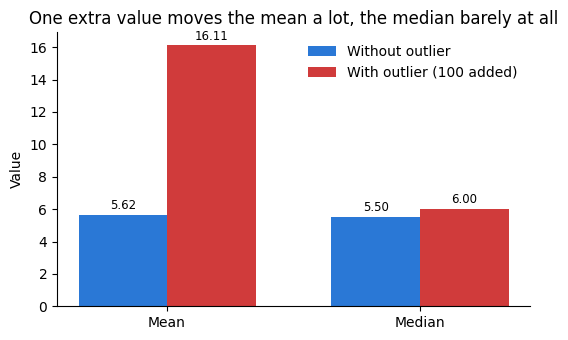

In [5]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Mean", "Median"]
without = [sum(l)/len(l), statistics.median(l)]
with_out = [sum(l_with_outlier)/len(l_with_outlier), statistics.median(l_with_outlier)]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(5.5, 3.5))
bars1 = ax.bar(x - width/2, without, width, label="Without outlier", color="#2a78d6")
bars2 = ax.bar(x + width/2, with_out, width, label="With outlier (100 added)", color="#d03b3b")
ax.bar_label(bars1, fmt="%.2f", padding=2, fontsize=8.5)
ax.bar_label(bars2, fmt="%.2f", padding=2, fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Value")
ax.set_title("One extra value moves the mean a lot, the median barely at all")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 1 — the proof, side by side.** Blue = the clean list,
red = the same list plus one outlier (red used deliberately as a "flagged/
critical" state, not just a fourth arbitrary color). The mean bar nearly
triples; the median bar barely shifts. Same underlying data, wildly
different sensitivity — which is exactly the property that makes outlier
handling a real decision, not a formality.

## 2. Why This Matters for ML Models, Not Just Arithmetic

The toy example proved outliers distort a plain average. In an actual ML
pipeline, that distortion shows up in more places than just `.mean()`:

- **Distance-based models** (KNN, K-Means) — a single far-away point can
  dominate a Euclidean-distance calculation, pulling cluster centers toward
  itself or making it the "nearest neighbor" to points it has nothing in
  common with.
- **Linear / Logistic Regression** — squared-error loss means one far-away
  point contributes a *disproportionately large* error term, giving it
  outsized leverage over the fitted coefficients (the line tilts to reduce
  that one huge error, at the cost of fitting everything else worse).
- **Feature scaling** (`StandardScaler`, `MinMaxScaler`) — exactly the std-dev
  problem from Section 1: one outlier stretches the scale, compressing every
  normal value into a narrow band and throwing away resolution where the
  real data actually lives.
- **Anything relying on mean-based statistics elsewhere in the pipeline** —
  e.g. mean-imputing a *different* column's missing values using a mean
  that an outlier already dragged off-center.

**Worth not overdoing:** this isn't "always delete every outlier." Tree-based
models (Decision Trees, Random Forest, XGBoost) split on ordered thresholds,
not distances, so they're relatively unbothered by an extreme value. And in
fraud detection, medical anomaly detection, etc., the outliers *are* the
thing you're trying to find — removing them would delete the signal, not
the noise. "Detect, then decide" (`02_ML_Roadmap.MD`'s phrasing) — removal
is one option, not the automatic answer.

## 3. Detecting Outliers — the Box Plot / IQR Method

| Part of the box plot | What it is |
|---|---|
| **Q1** | 25th percentile — a quarter of the data is below this |
| **Q3** | 75th percentile — three-quarters of the data is below this |
| **IQR** | `Q3 − Q1` — the width of the middle 50% of the data |
| **Median line** | the 50th percentile, drawn inside the box |
| **Lower whisker** | extends down to `Q1 − 1.5 × IQR` |
| **Upper whisker** | extends up to `Q3 + 1.5 × IQR` |
| **Outliers** | any point beyond either whisker — plotted as individual dots |

**The `1.5 × IQR` number isn't arbitrary.** For data that's genuinely
**normally distributed**, `Q1` and `Q3` sit at about `±0.6745σ` from the
mean, which puts the `1.5 × IQR` whiskers at about **`±2.698σ`**. Standard
normal tables say that range covers roughly **99.3%** of all data (`24.65%`
on each side of the median out to `±1σ`-ish, `50%` in the middle band) —
leaving only about **0.7% total (≈0.35% per tail)** expected to fall outside
as "true" outliers. That 0.7% is the benchmark to compare real data against
further down — if a real column flags a lot more than that, its shape isn't
actually normal, which is itself useful information.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
dataset = pd.read_csv("loans.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y


In [8]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            618 non-null    str    
 1   Gender             605 non-null    str    
 2   Married            612 non-null    str    
 3   Dependents         603 non-null    str    
 4   Education          609 non-null    str    
 5   Self_Employed      586 non-null    str    
 6   ApplicantIncome    616 non-null    float64
 7   CoapplicantIncome  618 non-null    int64  
 8   LoanAmount         596 non-null    float64
 9   Loan_Amount_Term   597 non-null    float64
 10  Credit_History     568 non-null    float64
 11  Property_Area      609 non-null    str    
 12  Loan_Status        618 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.9 KB


Two income columns stand out as the obvious candidates for outlier
checking — `ApplicantIncome` and `CoapplicantIncome` — both continuous,
both the kind of real-world financial figure that tends to have a long
right tail (most people earn a moderate amount; a few earn a lot).

In [9]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,616.000000,618.000000,596.000000,597.000000,568.000000
mean,4730.256494,1385.077670,223.031879,312.723618,0.836268
std,2180.942773,1611.760337,93.055097,89.102680,0.370359
min,1500.000000,0.000000,40.000000,36.000000,0.000000
25%,3160.500000,0.000000,152.000000,300.000000,1.000000
50%,4325.000000,1089.000000,208.500000,360.000000,1.000000
75%,5810.750000,2217.750000,282.000000,360.000000,1.000000
max,16981.000000,10288.000000,480.000000,360.000000,1.000000


One number already hints at the shape before any plot: `ApplicantIncome`'s
`mean` (4730) is noticeably higher than its `50%`/median (4325), and the
`max` (16981) is nearly 3x the `75%` value (5811) — classic signature of a
right-skewed column with high-end outliers pulling the mean up, exactly like
the toy example in Section 1.

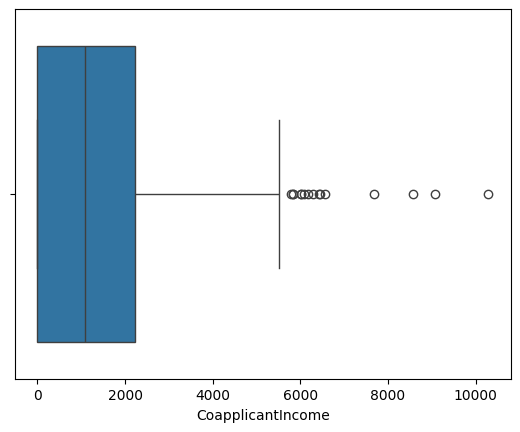

In [10]:
sns.boxplot(x="CoapplicantIncome",data=dataset)
plt.show()

A cluster of dots strung out to the right of the box — each one a row
flagged as beyond `Q3 + 1.5 × IQR`. Note the box itself sits low, hugging
`0` — a large share of applicants have **no** co-applicant income at all
(`Q1 = 0`, confirmed below), which is real, not an error; the outliers here
are the *co-applicants who do have income*, on the high end.

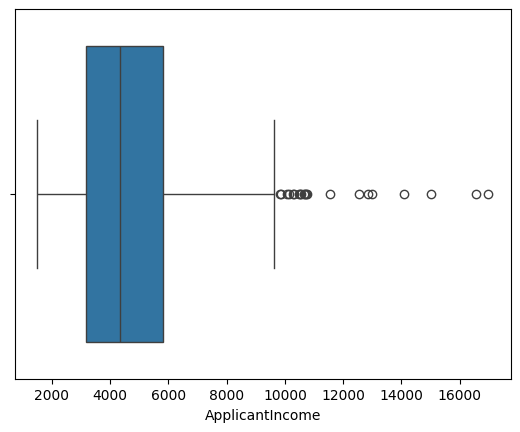

In [11]:
sns.boxplot(x="ApplicantIncome",data=dataset)
plt.show()

Same pattern, more outlier dots — `ApplicantIncome` has a longer tail of
high earners than `CoapplicantIncome` does. Visually convincing, but "a
cluster of dots" isn't a number — the next cell computes the exact bounds
and count the box plot is drawing from.

In [12]:
for col in ["ApplicantIncome", "CoapplicantIncome"]:
    s = dataset[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    is_outlier = (s < lower_bound) | (s > upper_bound)
    print(f"{col}: Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  "
          f"bounds=({lower_bound:.1f}, {upper_bound:.1f})  "
          f"outliers={is_outlier.sum()} ({100*is_outlier.mean():.2f}%)")

ApplicantIncome: Q1=3160.5  Q3=5810.8  IQR=2650.2  bounds=(-814.9, 9786.1)  outliers=21 (3.41%)
CoapplicantIncome: Q1=0.0  Q3=2217.8  IQR=2217.8  bounds=(-3326.6, 5544.4)  outliers=15 (2.43%)


The dots made numeric: `ApplicantIncome` flags **21 rows (3.41%)** beyond
`9786.1`; `CoapplicantIncome` flags **15 rows (2.43%)** beyond `5544.4`.
Both lower bounds come out **negative** (`-814.9` and `-3326.6`) — since
income can't be negative, there are effectively **zero low-end outliers**;
every flagged row is a high earner. Both percentages are well above the
**~0.7%** a normal distribution would predict (Section 3's table) —
confirming numerically what the skew in `.describe()` already hinted at.

## 4. The Distribution Graph — the Same Bounds, as a Bell Curve

The box plot and the distribution plot are two views of the same data —
the whiskers computed above are the box plot's outlier boundary; here
they're drawn over the actual density curve, matching the classic diagram
where the box plot sits directly above a bell curve with its tails
shaded as the outlier region.

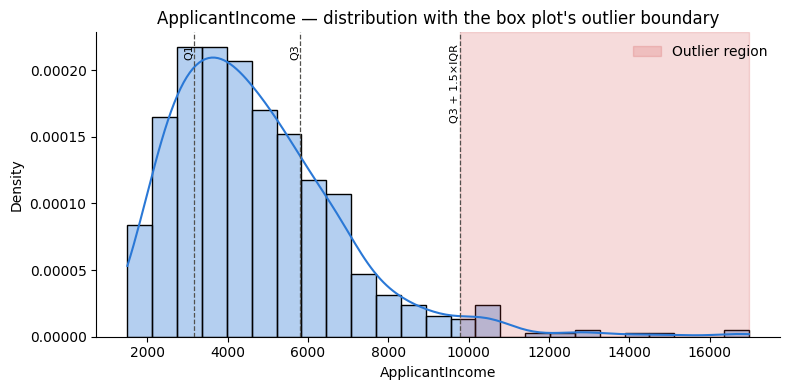

In [13]:
s = dataset["ApplicantIncome"].dropna()
Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(s, kde=True, color="#2a78d6", ax=ax, stat="density", alpha=0.35)

# Shade the outlier region in the tail that actually has data past the bound
ax.axvspan(upper_bound, s.max(), color="#d03b3b", alpha=0.18, label="Outlier region")
for val, label in [(Q1, "Q1"), (Q3, "Q3"), (upper_bound, "Q3 + 1.5×IQR")]:
    ax.axvline(val, color="#52514e", linestyle="--", linewidth=0.9)
    ax.text(val, ax.get_ylim()[1]*0.96, label, rotation=90, va="top", ha="right", fontsize=8)

ax.set_title("ApplicantIncome — distribution with the box plot's outlier boundary")
ax.set_xlabel("ApplicantIncome")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 2 — the distribution graph.** (Fixed from the original
`sns.distplot(...)` call, which is deprecated as of Seaborn 0.14 and prints
a `UserWarning` on every run — `sns.histplot(..., kde=True)` is the current
equivalent: a density histogram with the same smoothed curve on top.)

The blue curve is *not* a symmetric bell — it leans hard to the left with a
long right tail, unlike the perfectly symmetric normal curve in the
reference diagram. The red band marks everything past `Q3 + 1.5×IQR`: real,
non-empty mass sitting inside what the box plot calls "the outlier region."
This is the visual version of the 3.41% vs. 0.7% gap from Section 3 — a
symmetric normal curve would leave that red region nearly empty; this one
clearly doesn't.

## 5. IQR vs. Z-Score — Same Column, Different Assumptions

`02_ML_Roadmap.MD` names two detection methods: **IQR** (used above) and
**Z-score** (`|z| > 3`, i.e. more than 3 standard deviations from the mean).
Z-score assumes the data is roughly normal — exactly the assumption Section
4 just showed `ApplicantIncome` doesn't meet. Running both on the same
column shows the practical consequence.

In [14]:
mean, std = s.mean(), s.std()
z_scores = (s - mean) / std
iqr_outliers = (s < lower_bound) | (s > upper_bound)
z_outliers = z_scores.abs() > 3

print(f"IQR method:      {iqr_outliers.sum()} outliers flagged")
print(f"Z-score method:  {z_outliers.sum()} outliers flagged")
print(f"Flagged by IQR but not Z-score: {(iqr_outliers & ~z_outliers).sum()}")

IQR method:      21 outliers flagged
Z-score method:  8 outliers flagged
Flagged by IQR but not Z-score: 13


IQR flags **21**, Z-score flags only **8** — IQR catches 13 rows the
Z-score method misses entirely. That's the skew again: the mean and std dev
Z-score relies on are themselves inflated by the very outliers being
searched for (Section 1's whole point), so the `±3σ` cutoff sits further out
than it should. IQR, built from percentiles rather than the mean/std, isn't
thrown off the same way — which is why it's generally the safer default
for skewed real-world columns like this one, and Z-score is more
trustworthy on data that's actually close to normal.

## 6. Actually Removing Them

Detection answered "which rows"; this is "decide, then act" — the removal
half of `02_ML_Roadmap.MD`'s "detect → cap/remove/transform." Filtering to
just the rows *inside* the IQR bounds:

In [15]:
print("Shape before:", dataset.shape)

cleaned = dataset[(dataset["ApplicantIncome"] >= lower_bound) & (dataset["ApplicantIncome"] <= upper_bound)]

print("Shape after:", cleaned.shape)
print("Rows dropped:", dataset.shape[0] - cleaned.shape[0])

Shape before: (618, 13)
Shape after: (595, 13)
Rows dropped: 23


**618 → 595, 23 rows dropped** — one more than the 21 flagged as outliers
in Section 3. The extra 2: `ApplicantIncome` has 2 missing values
(`dataset.info()` showed `616 non-null` out of 618), and a comparison
against `NaN` (`NaN >= lower_bound`) always evaluates to `False` in pandas —
so the two `NaN` rows get filtered out along with the real outliers,
non-obviously. Worth being deliberate about: if the goal is *only* to drop
outliers (not also drop missing values), impute `ApplicantIncome` first,
the same way `07_Filling_Missing_Values.MD` and `09_one_hot_encoding.ipynb`
did for other columns, before applying this filter.

**Capping instead of dropping** (briefly, as the alternative `02_ML_Roadmap.MD`
also names): rather than removing rows outright — which loses whatever else
those rows recorded (`LoanAmount`, `Credit_History`, etc.) — replace values
past the bound with the bound itself: `dataset["ApplicantIncome"].clip(lower_bound, upper_bound)`.
That keeps every row while still preventing the extreme values from
dominating a mean, a distance calculation, or a scaler — worth reaching for
when the rest of a flagged row is still useful data.